## **Tugas 4: Encoder dan Graph**

### **Encoder**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW/tugas4/hasil_prepros.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal
0,"Apriyani Rahayu Sudah Berlatih Lagi, Ingin Com...","Rabu, 06 Nov 2024 15:25 WIB",Jakarta - Atlet bulutangkis Indonesia Apriyani...,Olahraga,Jakarta Atlet bulutangkis Indonesia Apriyani ...,jakarta atlet bulutangkis indonesia apriyani ...,"['jakarta', 'atlet', 'bulutangkis', 'indonesia...",jakarta atlet bulutangkis indonesia apriyani r...
1,Hasil Korea Masters 2024: Putri KW Lanjut ke 1...,"Rabu, 06 Nov 2024 14:36 WIB",Jakarta - Putri Kusuma Wardani hadapi wakil Ta...,Olahraga,Jakarta Putri Kusuma Wardani hadapi wakil Tai...,jakarta putri kusuma wardani hadapi wakil tai...,"['jakarta', 'putri', 'kusuma', 'wardani', 'had...",jakarta putri kusuma wardani hadapi wakil taiw...
2,Fajar/Rian di Japan dan China Masters: Inginny...,"Rabu, 06 Nov 2024 14:13 WIB",Jakarta - Fajar Alfian/Muhammad Rian Ardianto ...,Olahraga,Jakarta Fajar AlfianMuhammad Rian Ardianto be...,jakarta fajar alfianmuhammad rian ardianto be...,"['jakarta', 'fajar', 'alfianmuhammad', 'rian',...",jakarta fajar alfianmuhammad rian ardianto ber...
3,Hasil Korea Masters 2024: Komang Ayu Tersingkir,"Rabu, 06 Nov 2024 12:45 WIB",Jakarta - Komang Ayu Cahya Dewi hadapi Liang T...,Olahraga,Jakarta Komang Ayu Cahya Dewi hadapi Liang Ti...,jakarta komang ayu cahya dewi hadapi liang ti...,"['jakarta', 'komang', 'ayu', 'cahya', 'dewi', ...",jakarta komang ayu cahya dewi hadapi liang tin...
4,Korea Masters 2024 Hari Kedua: Tiga Wakil RI B...,"Rabu, 06 Nov 2024 10:55 WIB",Jakarta - Turnamen Korea Masters 2024 memasuki...,Olahraga,Jakarta Turnamen Korea Masters memasuki hari...,jakarta turnamen korea masters memasuki hari...,"['jakarta', 'turnamen', 'korea', 'masters', 'm...",jakarta turnamen korea masters memasuki penyel...


In [3]:
from sklearn.preprocessing import LabelEncoder

# Transformasi data kategorik
label_encoder = LabelEncoder()
df.loc[:, 'kategori_encoded'] = label_encoder.fit_transform(df['kategori'])

# Menampilkan nilai sebelum dan sesudah konversi
print("\nNilai sebelum dan sesudah konversi:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

print("\nDataFrame setelah Label Encoding:")
print(df)


Nilai sebelum dan sesudah konversi:
{'Olahraga': 0, 'Otomotif': 1}

DataFrame setelah Label Encoding:
                                                judul  \
0   Apriyani Rahayu Sudah Berlatih Lagi, Ingin Com...   
1   Hasil Korea Masters 2024: Putri KW Lanjut ke 1...   
2   Fajar/Rian di Japan dan China Masters: Inginny...   
3     Hasil Korea Masters 2024: Komang Ayu Tersingkir   
4   Korea Masters 2024 Hari Kedua: Tiga Wakil RI B...   
..                                                ...   
95  Inikah Motor Baru Honda yang Meluncur di Indon...   
96  Kenapa Harus Ganti Aki Meski Mobil Masih Kuat ...   
97  Biaya Bikin SIM A: Syarat, Cara Buat Baru, dan...   
98  Penjualan Mobil Turun, Kok Permintaan Motor Ma...   
99  Kawasaki W175 Injeksi Bakal Diproduksi Lokal M...   

                          tanggal  \
0     Rabu, 06 Nov 2024 15:25 WIB   
1     Rabu, 06 Nov 2024 14:36 WIB   
2     Rabu, 06 Nov 2024 14:13 WIB   
3     Rabu, 06 Nov 2024 12:45 WIB   
4     Rabu, 06 Nov 2024 10:

In [4]:
# Menyimpan DataFrame ke file CSV
df.to_csv('clear_text_cuy.csv', index=False)

### **Split Data**

In [5]:
from sklearn.model_selection import train_test_split

# Split data
x = df['stopword_removal']
y = df['kategori_encoded']

print(x)
print(y)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=12)

print("="*50)
print("Jumlah data latih:", len(x_train))
print("Jumlah data uji:", len(x_test))

0     jakarta atlet bulutangkis indonesia apriyani r...
1     jakarta putri kusuma wardani hadapi wakil taiw...
2     jakarta fajar alfianmuhammad rian ardianto ber...
3     jakarta komang ayu cahya dewi hadapi liang tin...
4     jakarta turnamen korea masters memasuki penyel...
                            ...                        
95    jakarta pt astra honda motor ahm meluncurkan p...
96    jakarta mobil distater menganggap kondisi aki ...
97    jakarta pengemudi mobil diwajibkan memiliki su...
98    jakarta berbeda mobil penjualan motor indonesi...
99    jakarta pt kawasaki motor indonesia kmi mempro...
Name: stopword_removal, Length: 100, dtype: object
0     0
1     0
2     0
3     0
4     0
     ..
95    1
96    1
97    1
98    1
99    1
Name: kategori_encoded, Length: 100, dtype: int64
Jumlah data latih: 80
Jumlah data uji: 20


### **TF-IDF Weighting**

In [6]:
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF Vectorizer
tfidf = TfidfVectorizer()

# Fit dan transform pada data training
x_train_tfidf = tfidf.fit_transform(x_train)

# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(x_train_tfidf.toarray(), columns=feature_names)

df_train_tfidf

,abadi,abdul,abs,absen,absennya,ac,acara,accident,accu,acosta,...,yra,yu,yuan,yuhsun,yzrm,zarco,zenix,zero,zf,zhi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.036097,0.0,0.0,0.0,...,0.0,0.000000,0.086085,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.117086,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.122434,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
76,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
77,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Ubah nilai TF-IDF di bawah 0.5 menjadi 0, dan di atas atau sama dengan 0.5 menjadi 1
df_train_tfidf_binary = df_train_tfidf.apply(lambda col: col.map(lambda x: 1 if x >= 0.5 else 0))

# Menampilkan DataFrame dengan nilai biner
df_train_tfidf_binary

,abadi,abdul,abs,absen,absennya,ac,acara,accident,accu,acosta,...,yra,yu,yuan,yuhsun,yzrm,zarco,zenix,zero,zf,zhi
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
76,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
77,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Membuat graf berdasarkan co-occurrence fitur
G = nx.Graph()

# Menambahkan node ke graf
for feature in df_train_tfidf_binary.columns:
    G.add_node(feature)

# Menambahkan edge berdasarkan co-occurrence
for i in range(len(df_train_tfidf_binary)):
    features = df_train_tfidf_binary.iloc[i]
    active_features = features[features == 1].index.tolist()

    for j in range(len(active_features)):
        for k in range(j + 1, len(active_features)):
            G.add_edge(active_features[j], active_features[k])

# Hitung degree centrality
degree_centrality = nx.degree_centrality(G)

# Konversi hasil degree centrality ke DataFrame untuk lebih mudah dilihat
df_degree_centrality = pd.DataFrame(degree_centrality.items(), columns=['Node', 'Degree Centrality'])

# Mengurutkan DataFrame dari yang terbesar sampai terkecil
df_degree_centrality_sorted = df_degree_centrality.sort_values(by='Degree Centrality', ascending=False)

# Tampilkan hasil degree centrality yang sudah diurutkan
print(df_degree_centrality_sorted)

              Node  Degree Centrality
2431           not           0.000521
586        content           0.000521
1075         found           0.000521
2556     pekerjaan           0.000000
2561    pelanpelan           0.000000
...            ...                ...
1284          imos           0.000000
1285  implementasi           0.000000
1286         impor           0.000000
1287          inch           0.000000
3836           zhi           0.000000

[3837 rows x 2 columns]


In [9]:
# Menghapus fitur di bawah top 10 terbaik
top_10_features = df_degree_centrality_sorted.head(10)['Node'].tolist()
filtered_df_train_tfidf_binary = df_train_tfidf_binary[top_10_features]

# Tampilkan hasil DataFrame yang sudah difilter
print("\nDataFrame setelah menghapus fitur di bawah top 10:")
print(filtered_df_train_tfidf_binary)


DataFrame setelah menghapus fitur di bawah top 10:
    not  content  found  pekerjaan  pelanpelan  pelanggan  pelaku  pelaksana  \
0     0        0      0          0           0          0       0          0   
1     0        0      0          0           0          0       0          0   
2     0        0      0          0           0          0       0          0   
3     0        0      0          0           0          0       0          0   
4     0        0      0          0           0          0       0          0   
..  ...      ...    ...        ...         ...        ...     ...        ...   
75    0        0      0          0           0          0       0          0   
76    0        0      0          0           0          0       0          0   
77    0        0      0          0           0          0       0          0   
78    0        0      0          0           0          0       0          0   
79    0        0      0          0           0          0       0   

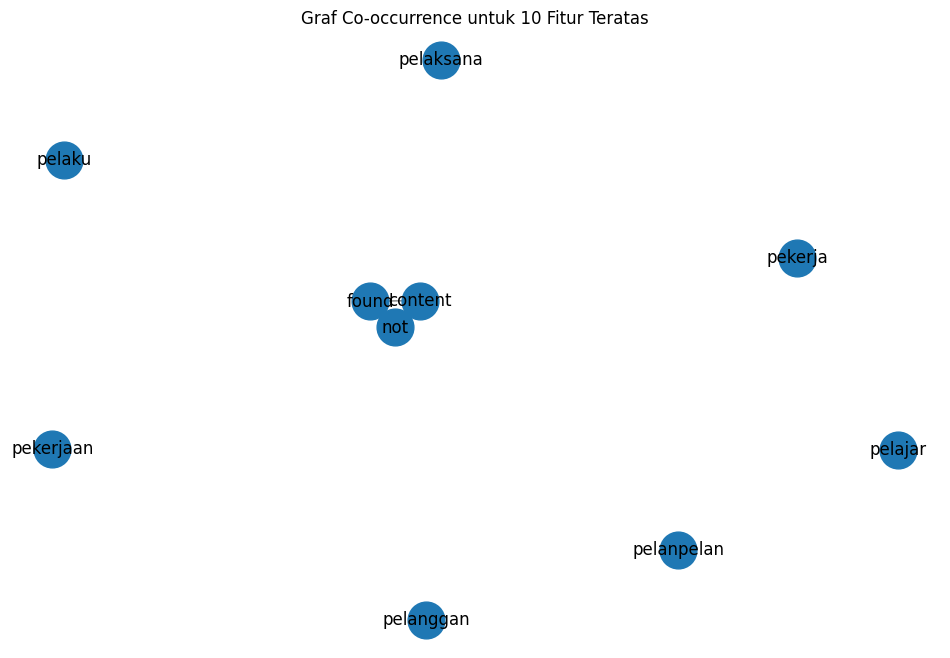

In [10]:
import matplotlib.pyplot as plt

# Membuat graf baru hanya untuk fitur teratas
G_top_10 = nx.Graph()

# Menambahkan node teratas ke graf
for feature in top_10_features:
    G_top_10.add_node(feature)

# Menambahkan edge berdasarkan co-occurrence dari fitur teratas
for i in range(len(df_train_tfidf_binary)):
    features = df_train_tfidf_binary.iloc[i]
    active_features = features[features == 1].index.tolist()
    active_top_10_features = [f for f in active_features if f in top_10_features]

    for j in range(len(active_top_10_features)):
        for k in range(j + 1, len(active_top_10_features)):
            G_top_10.add_edge(active_top_10_features[j], active_top_10_features[k])

# Mengatur ukuran figure untuk visualisasi graf
plt.figure(figsize=(12, 8))

# Menggambar graf fitur teratas
pos = nx.spring_layout(G_top_10)  # Menggunakan layout spring
nx.draw_networkx_nodes(G_top_10, pos, node_size=700)  # Menggambar node
nx.draw_networkx_edges(G_top_10, pos, width=1.0, alpha=0.5)  # Menggambar edge
nx.draw_networkx_labels(G_top_10, pos, font_size=12, font_family='sans-serif')  # Menggambar label

# Menampilkan graf
plt.title('Graf Co-occurrence untuk 10 Fitur Teratas')
plt.axis('off')  # Menyembunyikan sumbu
plt.show()

In [11]:
# Menghitung closeness centrality
closeness_centrality = nx.closeness_centrality(G_top_10)

# Menghitung betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G_top_10)

# Konversi hasil centrality ke DataFrame untuk lebih mudah dilihat
df_closeness_centrality = pd.DataFrame(closeness_centrality.items(), columns=['Node', 'Closeness Centrality'])
df_betweenness_centrality = pd.DataFrame(betweenness_centrality.items(), columns=['Node', 'Betweenness Centrality'])

# Menggabungkan semua centrality ke dalam satu DataFrame
df_centrality = pd.merge(df_degree_centrality_sorted, df_closeness_centrality, on='Node')
df_centrality = pd.merge(df_centrality, df_betweenness_centrality, on='Node')

# Menampilkan hasil centrality
print(df_centrality)

         Node  Degree Centrality  Closeness Centrality  Betweenness Centrality
0         not           0.000521              0.222222                     0.0
1     content           0.000521              0.222222                     0.0
2       found           0.000521              0.222222                     0.0
3   pekerjaan           0.000000              0.000000                     0.0
4  pelanpelan           0.000000              0.000000                     0.0
5   pelanggan           0.000000              0.000000                     0.0
6      pelaku           0.000000              0.000000                     0.0
7   pelaksana           0.000000              0.000000                     0.0
8     pelajar           0.000000              0.000000                     0.0
9     pekerja           0.000000              0.000000                     0.0


###**Kedua: Ambil Satu Berita**

In [18]:
# Mengimpor library yang diperlukan
import pandas as pd

# Teks berita yang telah dirapikan
news_text_1 = """ Putri Kusuma Wardani hadapi wakil Taiwan, Huang Yu-Hsun di Korea Masters 2024. Putri KW menang dua gim langsung dan
kunci tiket ke babak 16 besar! Korea Masters 2024 berlangsung di Iksan City, Korea Selatan, Rabu (6/1). Hari ini merupakan perebutan
tiket ke babak 16 besar. Di nomor tunggal putri, Putri Kusuma Wardani ditantang Huang Yu-Hsun. Putri KW menangi gim pertama 21-4 dan
menangi gim kedua .. Gim pertama dimulai, Putri KW langsung pegang kendali. Dirinya nyaman memimpin 7-1, lalu unggul di interval 11-2.
Putri KW terus tancap gas. Tak butuh waktu lama, dirinya sudahi gim pertama dengan kemenangan telak 21-4. Gim kedua, Huang Yu-Hsun
coba bangkit dengan unggul duluan 3-1. Putri KW langsung menyalipnya, 4-3 dan unggul di interval 11-4. Putri KW terus memimpin 15-5.
Selanjutnya, Putri KW mampu kunci gim kedua dengan kemenangan 21-9. """

news_text_2 = """ Suzuki Motor Corporation resmi meluncurkan mobil listrik bertenaga baterai (BEV) pertamanya. Mobil listrik hasil
produksi massal dari eVX itu dijual dengan nama e Vitara. Suzuki meluncurkan e Vitara pertama kali di Eropa, tepatnya di Milan, Italia.
Produksi akan dimulai di Suzuki Motor Gujarat di India pada 2025. Mobil ini akan mulai dijual di berbagai negara, termasuk Eropa,
India, dan Jepang, sekitar pertengahan tahun 2025. ""e VITARA adalah BEV pertama kami, yang dikembangkan melalui uji coba berulang
kali untuk menciptakan BEV yang mudah digunakan bagi pelanggan kami. Untuk mewujudkan masyarakat yang netral karbon, kami akan menyediakan
berbagai pilihan, termasuk BEV, kendaraan hybrid, dan kendaraan CNG, yang disesuaikan dengan wilayah tertentu,"" kata Toshihiro Suzuki,
Representative Director and President Suzuki Motor Corporation dikutip dari siaran persnya ""Peluncuran e VITARA merupakan tonggak penting
dalam mencapai netralitas karbon. Setelah peluncuran e VITARA, kami akan terus memperluas jajaran BEV kami dan mengusulkan solusi mobilitas
yang disesuaikan dengan kebutuhan negara dan wilayah tertentu"". """

# Mengubah teks menjadi DataFrame
data = pd.DataFrame([news_text_1, news_text_2], columns=['text'])

# Menampilkan DataFrame
print(data)


                                                text
0   Putri Kusuma Wardani hadapi wakil Taiwan, Hua...
1   Suzuki Motor Corporation resmi meluncurkan mo...


In [19]:
# Mengimpor library yang diperlukan
from sklearn.feature_extraction.text import TfidfVectorizer

# Menghitung TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(data['text'])

# Mengambil nama fitur (kata) dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Menghitung skor TF-IDF untuk setiap fitur
tfidf_scores = tfidf_matrix.toarray()
df_tfidf_scores = pd.DataFrame(tfidf_scores, columns=feature_names)

# Mengurutkan DataFrame berdasarkan skor TF-IDF dari terbesar ke terkecil
df_top_features = df_tfidf_scores.sum(axis=0).reset_index()
df_top_features.columns = ['Feature', 'Score']

# Pastikan kolom 'Score' adalah tipe data numerik
df_top_features['Score'] = pd.to_numeric(df_top_features['Score'], errors='coerce')

# Mengurutkan berdasarkan skor
df_top_features = df_top_features.sort_values(by='Score', ascending=False)

# Mengambil 10 fitur terbaik
top_10_features = df_top_features.head(10)

# Menampilkan 10 fitur terbaik
print("10 Fitur Terbaik:\n", top_10_features)

10 Fitur Terbaik:
     Feature     Score
119   putri  0.501649
28       di  0.375537
43      gim  0.351154
72       kw  0.351154
152    yang  0.276980
60     kami  0.276980
18      bev  0.276980
130  suzuki  0.276980
147  vitara  0.276980
25      dan  0.264737


In [20]:
# Mengimpor library yang diperlukan
from sklearn.metrics.pairwise import cosine_similarity

# Mengambil hanya nama fitur dari 10 fitur teratas
top_10_feature_names = top_10_features['Feature'].values

# Mengambil indeks fitur di vocabulary
top_10_feature_indices = [tfidf_vectorizer.vocabulary_[feature] for feature in top_10_feature_names]

# Mengambil kolom TF-IDF untuk 10 fitur teratas
top_10_tfidf_matrix = tfidf_matrix[:, top_10_feature_indices]

# Menghitung cosine similarity
cosine_sim = cosine_similarity(top_10_tfidf_matrix.T)

# Mengubah hasil cosine similarity menjadi DataFrame untuk kemudahan analisis
cosine_sim_df = pd.DataFrame(cosine_sim, index=top_10_feature_names, columns=top_10_feature_names)

# Menampilkan cosine similarity
print("Cosine Similarity Matrix:\n", cosine_sim_df)

Cosine Similarity Matrix:
            putri        di       gim        kw      yang      kami       bev  \
putri   1.000000  0.671242  1.000000  1.000000  0.000000  0.000000  0.000000   
di      0.671242  1.000000  0.671242  0.671242  0.741238  0.741238  0.741238   
gim     1.000000  0.671242  1.000000  1.000000  0.000000  0.000000  0.000000   
kw      1.000000  0.671242  1.000000  1.000000  0.000000  0.000000  0.000000   
yang    0.000000  0.741238  0.000000  0.000000  1.000000  1.000000  1.000000   
kami    0.000000  0.741238  0.000000  0.000000  1.000000  1.000000  1.000000   
bev     0.000000  0.741238  0.000000  0.000000  1.000000  1.000000  1.000000   
suzuki  0.000000  0.741238  0.000000  0.000000  1.000000  1.000000  1.000000   
vitara  0.000000  0.741238  0.000000  0.000000  1.000000  1.000000  1.000000   
dan     0.561844  0.990318  0.561844  0.561844  0.827243  0.827243  0.827243   

          suzuki    vitara       dan  
putri   0.000000  0.000000  0.561844  
di      0.7412

In [21]:
# Menambahkan klasifikasi berdasarkan nilai cosine similarity
classification = (cosine_sim_df >= 0.5).astype(int)

# Menampilkan DataFrame klasifikasi
print("\nClassification Matrix:\n", classification)



Classification Matrix:
         putri  di  gim  kw  yang  kami  bev  suzuki  vitara  dan
putri       1   1    1   1     0     0    0       0       0    1
di          1   1    1   1     1     1    1       1       1    1
gim         1   1    1   1     0     0    0       0       0    1
kw          1   1    1   1     0     0    0       0       0    1
yang        0   1    0   0     1     1    1       1       1    1
kami        0   1    0   0     1     1    1       1       1    1
bev         0   1    0   0     1     1    1       1       1    1
suzuki      0   1    0   0     1     1    1       1       1    1
vitara      0   1    0   0     1     1    1       1       1    1
dan         1   1    1   1     1     1    1       1       1    1


In [22]:
# Membuat graf dari matriks klasifikasi
G = nx.from_pandas_adjacency(classification)

# Menghitung degree
degree = dict(G.degree())
print("\nDegree:\n", degree)

# Menghitung closeness centrality
closeness = nx.closeness_centrality(G)
print("\nCloseness Centrality:\n", closeness)

# Menghitung betweenness centrality
betweenness = nx.betweenness_centrality(G)
print("\nBetweenness Centrality:\n", betweenness)


Degree:
 {'putri': 6, 'di': 11, 'gim': 6, 'kw': 6, 'yang': 8, 'kami': 8, 'bev': 8, 'suzuki': 8, 'vitara': 8, 'dan': 11}

Closeness Centrality:
 {'putri': 0.6428571428571429, 'di': 1.0, 'gim': 0.6428571428571429, 'kw': 0.6428571428571429, 'yang': 0.75, 'kami': 0.75, 'bev': 0.75, 'suzuki': 0.75, 'vitara': 0.75, 'dan': 1.0}

Betweenness Centrality:
 {'putri': 0.0, 'di': 0.20833333333333331, 'gim': 0.0, 'kw': 0.0, 'yang': 0.0, 'kami': 0.0, 'bev': 0.0, 'suzuki': 0.0, 'vitara': 0.0, 'dan': 0.20833333333333331}


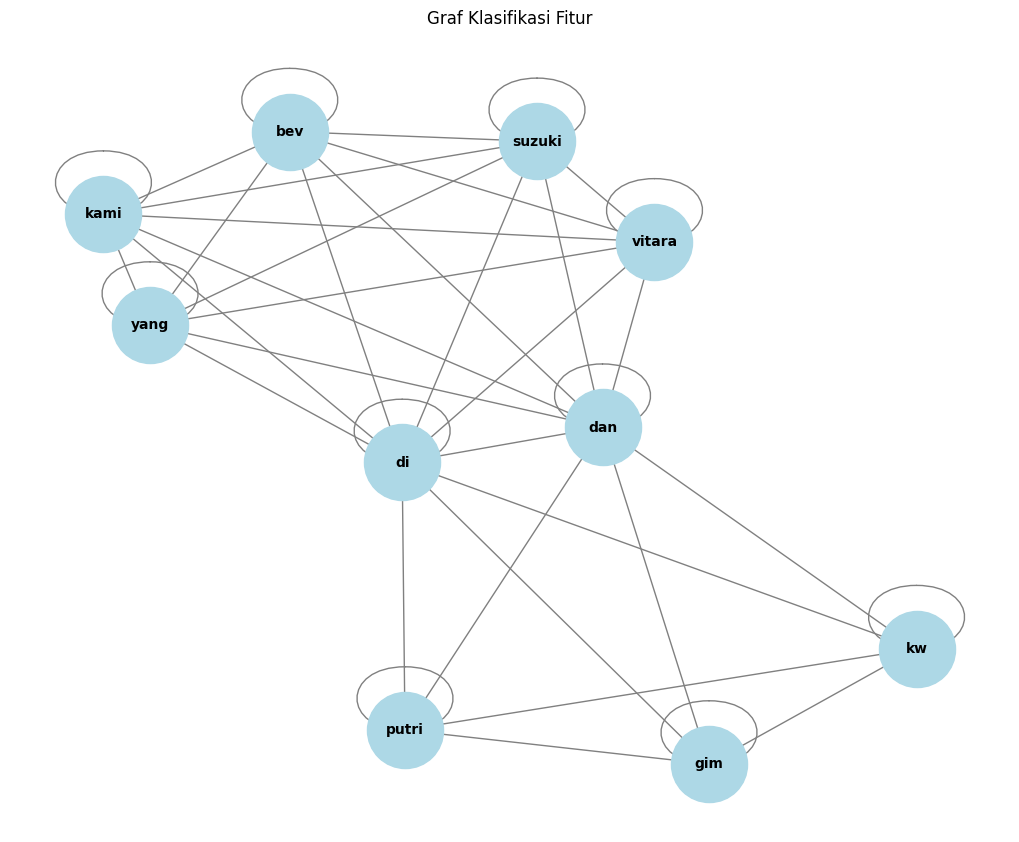

In [23]:
import matplotlib.pyplot as plt
import networkx as nx

# Mengubah hasil cosine similarity menjadi DataFrame untuk kemudahan analisis
cosine_sim_df = pd.DataFrame(cosine_sim, index=top_10_feature_names, columns=top_10_feature_names)

# Menambahkan klasifikasi berdasarkan nilai cosine similarity
classification = (cosine_sim_df >= 0.5).astype(int)

# Membuat graf dari matriks klasifikasi
G = nx.from_pandas_adjacency(classification)

# Menggambar graf
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Menggunakan spring layout untuk penempatan node
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=3000, font_size=10, font_weight='bold')
plt.title("Graf Klasifikasi Fitur")
plt.show()